# The Beveridge curve, at home and abroad

**How can unemployment be high while firms cannot fill jobs?** The
Beveridge curve — vacancies against unemployment — is the labor market's
supply-and-demand cross (Blanchard-Diamond 1989). Movements *along* it are
the business cycle: booms slide up-left (many vacancies, few unemployed),
recessions down-right. Movements *of* it are structural: worse matching
shifts the whole locus outward. After COVID the US curve became the
center of a policy fight — could vacancies fall without unemployment
rising (Figura-Waller 2022), or would disinflation require a recession
(Blanchard-Domash-Summers 2022)? This notebook draws the evidence with
the package's two vacancy fetchers: **JOLTS** for the US
(`puremacro.fetch.jolts`) and **Eurostat job-vacancy statistics** for
Europe (`puremacro.fetch.vacancies_eurostat`), both frozen offline here.

## The matching function in math

The workhorse model (Pissarides 2000; survey in Petrongolo-Pissarides
2001) generates the curve from a matching technology
$$ M_t = \mu\, U_t^{\alpha} V_t^{1-\alpha}, $$
hires produced from the stocks of job seekers $U$ and vacancies $V$.
Define tightness $\theta = V/U$. The job-finding rate is
$$ f_t = M_t / U_t = \mu\, \theta_t^{1-\alpha}, $$
so on a log-log plot of $f$ against $\theta$ the slope IS $1-\alpha$. In
steady state, inflows to unemployment $s(1-u)$ equal outflows $f\,u$,
which traces the downward-sloping locus
$$ u = \frac{s}{s + \mu \theta^{1-\alpha}} $$
— the Beveridge curve. A rise in match efficiency $\mu$ shifts it inward;
a rise in separations $s$ or mismatch shifts it outward. JOLTS measures
every object in these equations directly: openings ($V$), hires ($M$),
quits and layoffs (the two faces of $s$).

**Intuition.** The curve slopes down because vacancies and unemployment
are two sides of one friction: when jobs are easy to fill, few postings
sit open and many workers sit idle; when workers are scarce the postings
pile up. The *loop* direction is informative too — after a shock the
economy circles the curve counter-clockwise, because vacancies adjust in
weeks while the unemployment pool drains slowly. And the post-2021 US
episode is the cleanest natural experiment the curve has ever produced:
vacancies fell from historic highs with almost no rise in unemployment —
a nearly vertical descent that neither side of the 2022 debate predicted
in full.

## Setup — two frozen panels

Frozen by `tools/gen_notebook_data_beveridge18.py` from the batch-5a
fetchers (key-free fredgraph JOLTS + Eurostat `jvs_q_nace2` via the
house SDMX layer):

- `beveridge18_us.csv` — monthly SA: UNRATE, unemployment level, JOLTS
  openings/hires/quits (levels + rates), 2000-12 onward.
- `beveridge18_eu.csv` — quarterly: Eurostat job vacancy rate (NACE
  B-S business economy, all size classes, SA) merged with the LFS
  urate, ISO-3 codes, 29 countries.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.replication._data import load_csv

us = load_csv("beveridge18_us")
us["date"] = pd.to_datetime(us["date"])
eu = load_csv("beveridge18_eu")
eu["date"] = pd.to_datetime(eu["date"])
print(f"US: {len(us)} months {us['date'].min().date()}..{us['date'].max().date()}")
print(f"EU: {eu['code'].nunique()} countries, {len(eu)} country-quarters")

ERAS = [
    ("2001-2007", "2000-12-01", "2007-11-30", "#2a78d6"),
    ("2008-2019", "2007-12-01", "2019-12-31", "#008300"),
    ("COVID 2020", "2020-01-01", "2020-12-31", "#e34948"),
    ("2021+", "2021-01-01", "2099-01-01", "#eda100"),
]

US: 305 months 2000-12-01..2026-05-01
EU: 29 countries, 1825 country-quarters


## The US curve, era by era

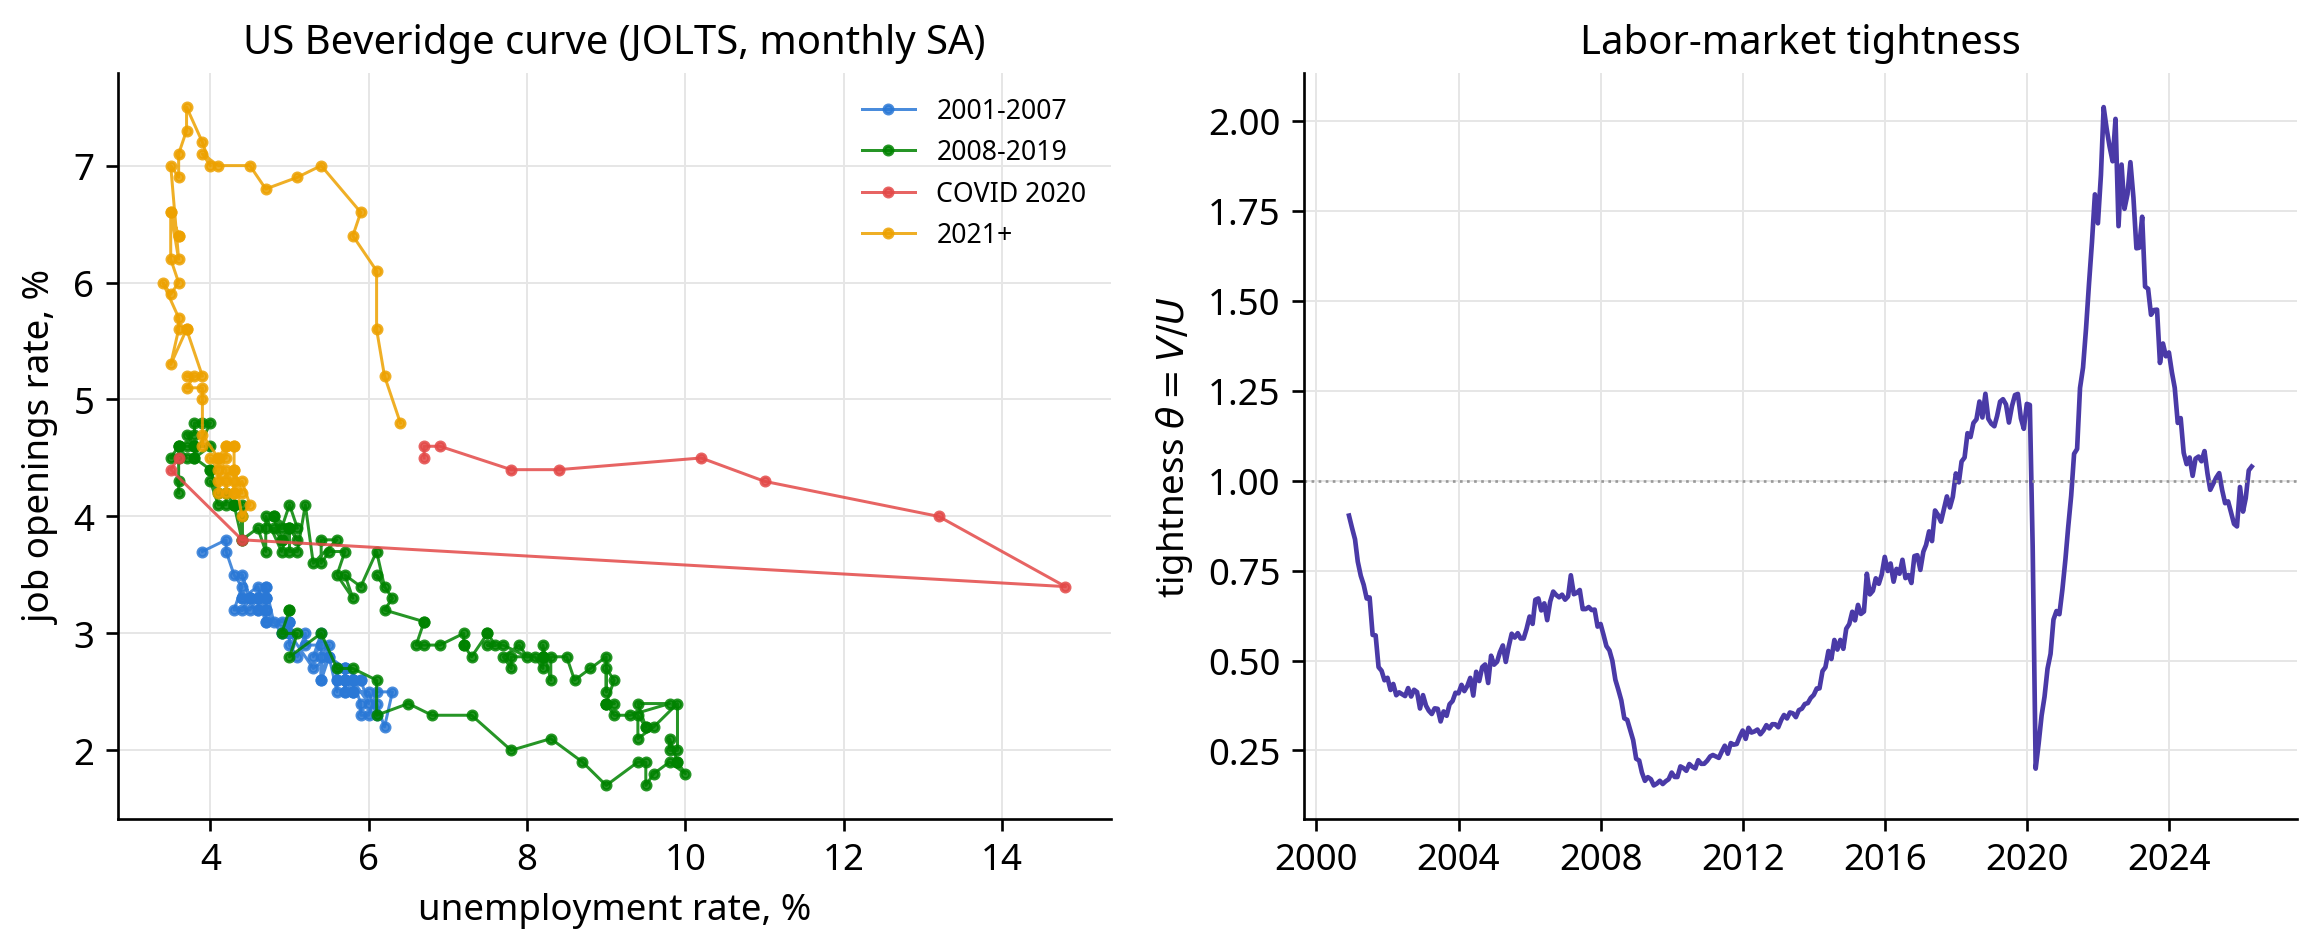

peak tightness: 2.04 vacancies per unemployed (2022-03-01)


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(9.8, 4.1))
ax = axes[0]
for name, lo, hi, c in ERAS:
    m = (us["date"] >= lo) & (us["date"] <= hi)
    ax.plot(us.loc[m, "urate"], us.loc[m, "v_rate"], "-o", color=c,
            ms=2.6, lw=0.9, alpha=0.85, label=name)
ax.set_xlabel("unemployment rate, %")
ax.set_ylabel("job openings rate, %")
ax.set_title("US Beveridge curve (JOLTS, monthly SA)")
ax.legend(fontsize=8)

ax = axes[1]
us["theta"] = us["v_level"] / us["unemp_level"]
ax.plot(us["date"], us["theta"], color="#4a3aa7", lw=1.4)
ax.axhline(1.0, color="0.6", lw=0.8, ls=":")
ax.set_ylabel(r"tightness $\theta = V/U$")
ax.set_title("Labor-market tightness")
plt.tight_layout(); plt.show()

peak_theta = us.loc[us["theta"].idxmax()]
print(f"peak tightness: {peak_theta['theta']:.2f} vacancies per unemployed "
      f"({peak_theta['date'].date()})")
assert us["theta"].max() > 1.5, "the 2022 tightness peak should exceed 1.5"

**Reading the loop.** The 2008-2019 era traces one full counter-clockwise
circuit: the crash slides down-right along a stable curve, the recovery
climbs back on a visibly *outer* path (the 2010-13 shift that launched a
mismatch literature), then re-tightens. COVID is the vertical spike —
unemployment tripled in two months while vacancies barely moved. The
2021+ segment is the historic one: tightness peaked around two vacancies
per unemployed worker, and the descent from that peak runs almost
straight down — large vacancy declines, minimal unemployment rise.

## Estimating the matching elasticity

The job-finding proxy $f = \text{hires}/U$ against tightness
$\theta = V/U$, in logs: the slope estimates $1-\alpha$. Two honest
caveats baked into the printout: JOLTS hires include job-to-job moves
(numerator too big), and OLS on the aggregate ignores endogeneity and
time aggregation — this is the descriptive benchmark regression of
Petrongolo-Pissarides (2001), not a causal estimate.

In [3]:
d = us.dropna(subset=["hires_level", "unemp_level", "theta"]).copy()
logf = np.log(d["hires_level"] / d["unemp_level"])
logth = np.log(d["theta"])
X = np.column_stack([np.ones(len(d)), logth])
b, *_ = np.linalg.lstsq(X, logf, rcond=None)
resid = logf - X @ b
r2 = 1 - resid.var() / logf.var()
alpha = 1 - b[1]
print(f"log f = {b[0]:+.3f} + {b[1]:.3f} log theta   (R2 {r2:.3f})")
print(f"=> matching elasticity on unemployment alpha = {alpha:.3f}")
assert 0.2 < alpha < 0.9, "alpha should land in the literature's broad range"

log f = -0.195 + 0.592 log theta   (R2 0.877)
=> matching elasticity on unemployment alpha = 0.408


## Europe: same curve, different frictions

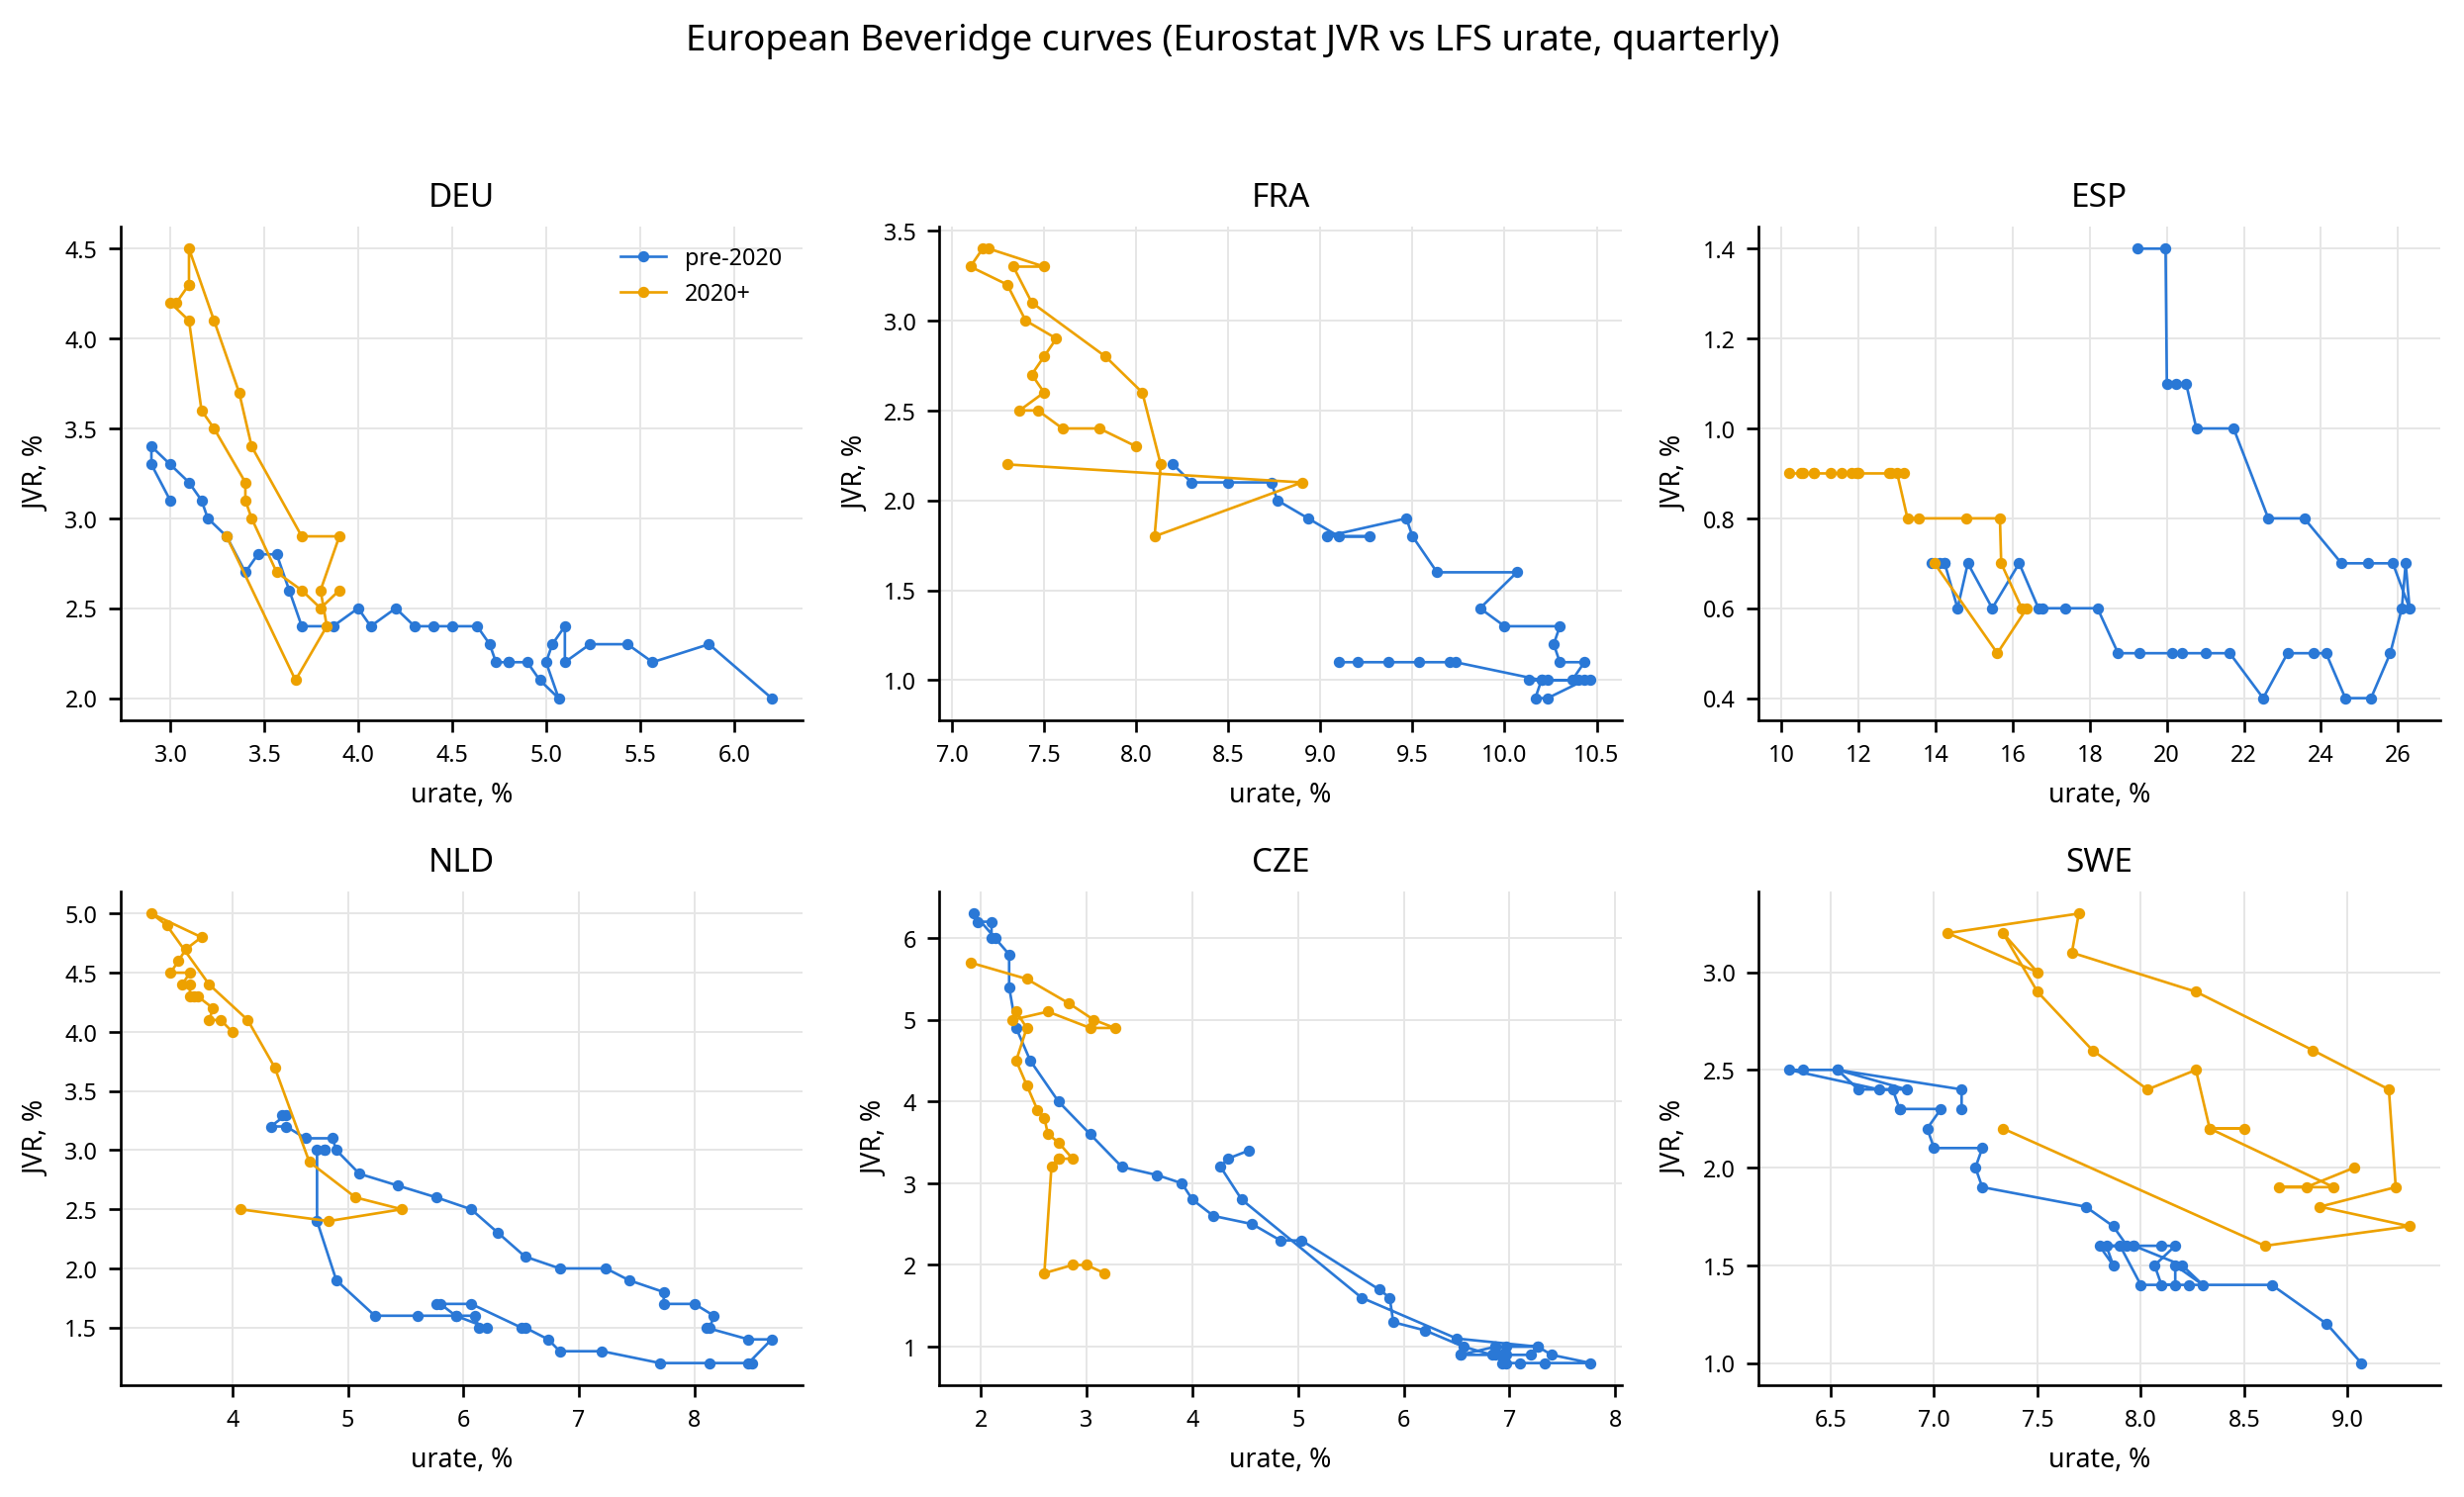

countries plotted: ['DEU', 'FRA', 'ESP', 'NLD', 'CZE', 'SWE']


In [4]:
# Curated majors first (pedagogy), backfilled by longest coverage.
_prefer = ["DEU", "FRA", "ESP", "NLD", "CZE", "SWE"]
_counts = eu.groupby("code")["date"].count()
top6 = [c for c in _prefer if _counts.get(c, 0) >= 30]
top6 += [c for c in _counts.sort_values(ascending=False).index
         if c not in top6][: 6 - len(top6)]
fig, axes = plt.subplots(2, 3, figsize=(10.5, 6.4), sharey=False)
for ax, code in zip(axes.ravel(), top6):
    g = eu[eu["code"] == code].sort_values("date")
    pre = g[g["date"] < "2020-01-01"]
    post = g[g["date"] >= "2020-01-01"]
    ax.plot(pre["urate"], pre["jvr"], "-o", color="#2a78d6", ms=2.4,
            lw=0.8, label="pre-2020")
    ax.plot(post["urate"], post["jvr"], "-o", color="#eda100", ms=2.4,
            lw=0.8, label="2020+")
    ax.set_title(code, fontsize=10)
    ax.set_xlabel("urate, %", fontsize=8)
    ax.set_ylabel("JVR, %", fontsize=8)
    ax.tick_params(labelsize=7)
axes[0, 0].legend(fontsize=7)
fig.suptitle("European Beveridge curves (Eurostat JVR vs LFS urate, "
             "quarterly)", fontsize=11)
plt.tight_layout(rect=(0, 0, 1, 0.95)); plt.show()
print("countries plotted:", top6)

**Cross-country reading.** The same downward cloud appears everywhere,
but its *position* differs by an order of magnitude in the u-direction:
economies with high structural unemployment operate far to the right at
the same vacancy rate — the friction is not cyclical slack but matching
and institutions. The 2020+ points sit above and left of each country's
own pre-2020 cloud in most panels: the post-COVID tightening was a
continent-wide phenomenon, not a US peculiarity.

## Does uncertainty bite harder in a slack labor market?

The curve gives us a *regime variable*: tightness $\theta$. Theory says
shocks should transmit differently along the curve — in a slack market
(low $\theta$) a demand or uncertainty shock meets abundant idle labor
and wage rigidity; in a tight one it mostly reshuffles vacancies. The
package's smooth-transition local projections
(`puremacro.lp.lp_state_dep`, the notebook-07 machinery) estimate both
responses at once, weighting each month by a logistic function of
standardized $\log\theta$. The shock here is the EPU uncertainty proxy
from the notebook-17 panel (same frozen file), with its own lags as
controls — descriptive state-dependence, not a structural claim.

merged monthly sample: 305 months 2000-12-01..2026-05-01


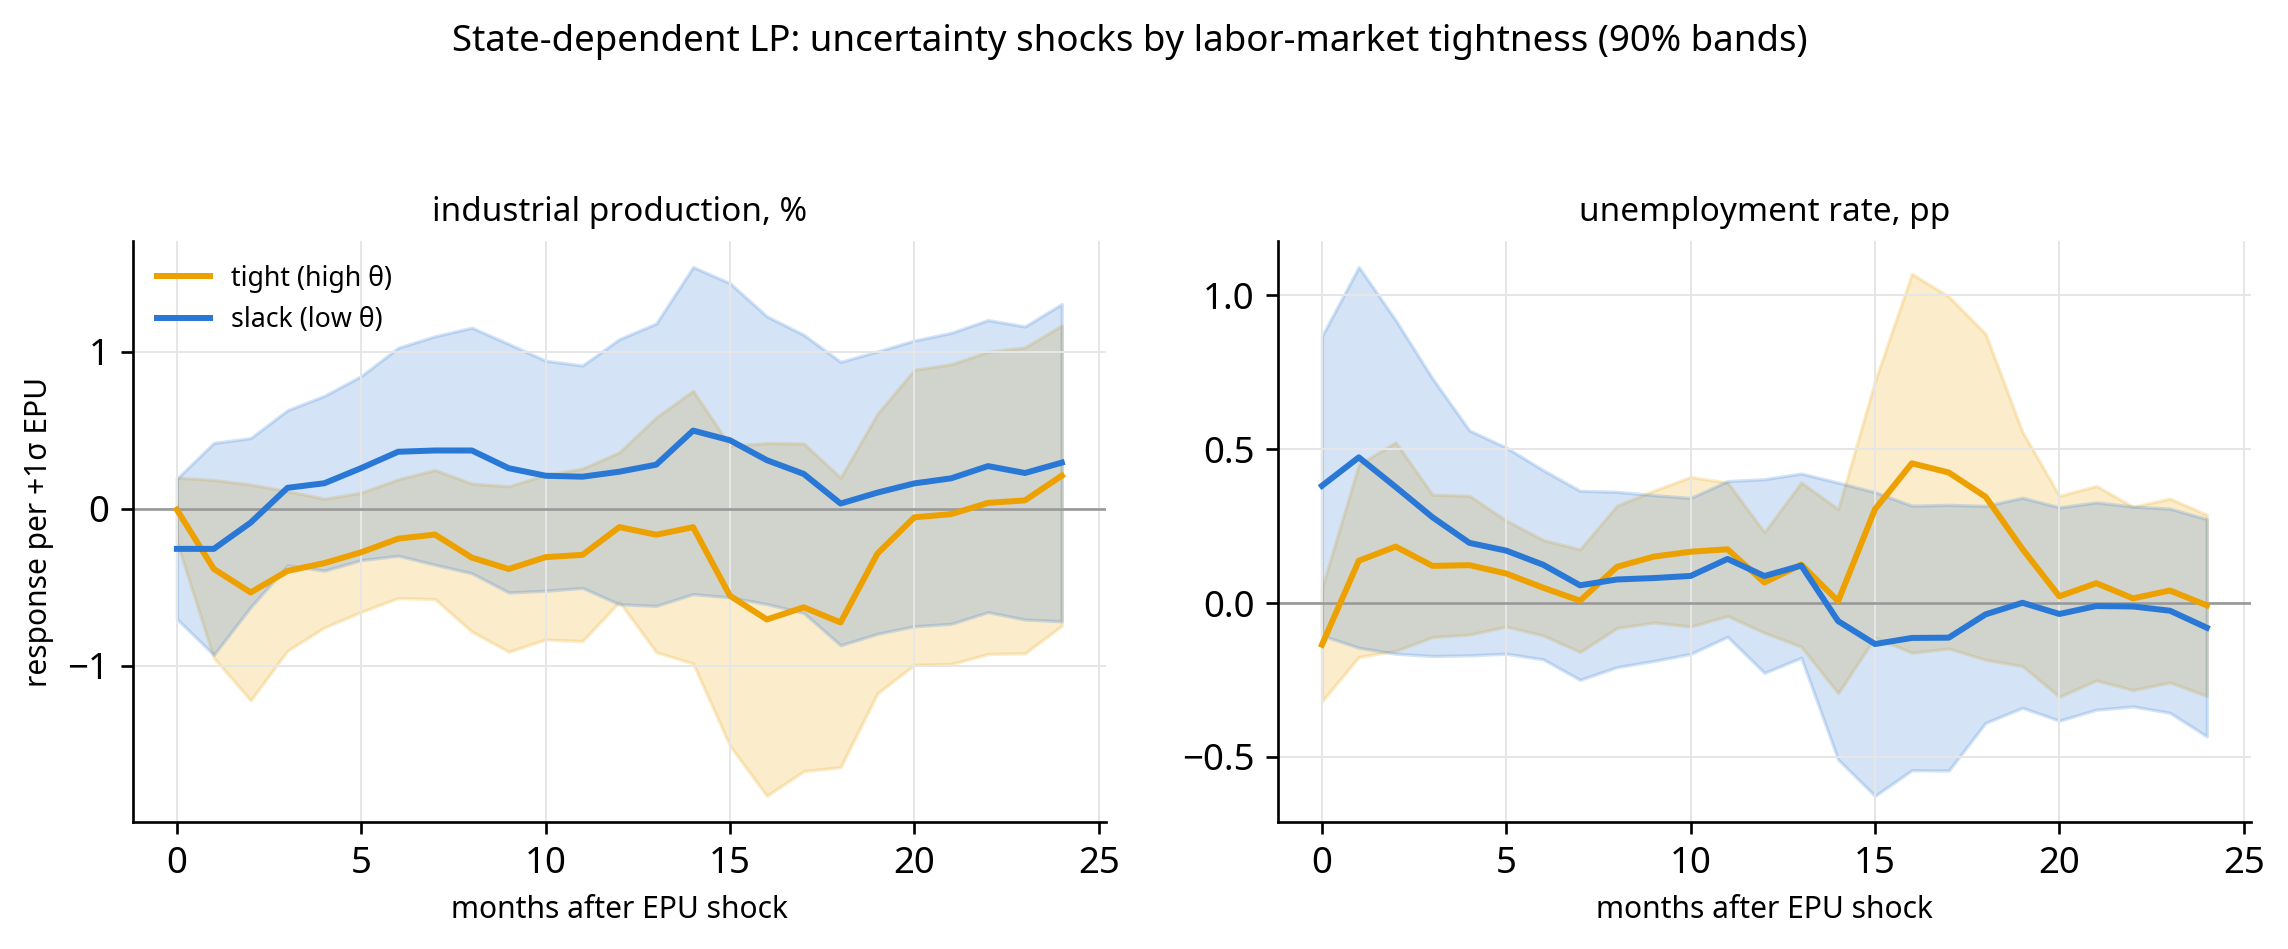

IP at h=12: slack +0.24 [-0.61,+1.08] vs tight -0.12 [-0.59,+0.36]


In [5]:
from puremacro.lp import lp_state_dep

spec = load_csv("speccurve17_panel")
spec["date"] = pd.to_datetime(spec["date"])
m = spec.merge(us[["date", "urate", "theta"]], on="date", how="inner")
m["log_theta"] = np.log(m["theta"])
print(f"merged monthly sample: {len(m)} months "
      f"{m['date'].min().date()}..{m['date'].max().date()}")

fig, axes = plt.subplots(1, 2, figsize=(9.8, 4.0))
for ax, yvar, lab in ((axes[0], "ip", "industrial production, %"),
                      (axes[1], "urate", "unemployment rate, pp")):
    r = lp_state_dep(m, y=yvar, x="epu", state="log_theta",
                     horizons=range(0, 25), n_lags=6)
    ax.axhline(0, color="0.6", lw=0.8)
    ax.fill_between(r["h"], r["lo_H"], r["hi_H"], color="#eda100",
                    alpha=0.20)
    ax.plot(r["h"], r["beta_H"], color="#eda100", lw=1.8,
            label="tight (high θ)")
    ax.fill_between(r["h"], r["lo_L"], r["hi_L"], color="#2a78d6",
                    alpha=0.20)
    ax.plot(r["h"], r["beta_L"], color="#2a78d6", lw=1.8,
            label="slack (low θ)")
    ax.set_xlabel("months after EPU shock", fontsize=9)
    ax.set_title(lab, fontsize=10)
axes[0].set_ylabel("response per +1σ EPU", fontsize=9)
axes[0].legend(fontsize=8)
fig.suptitle("State-dependent LP: uncertainty shocks by labor-market "
             "tightness (90% bands)", fontsize=11)
plt.tight_layout(rect=(0, 0, 1, 0.92)); plt.show()

r_ip = lp_state_dep(m, y="ip", x="epu", state="log_theta",
                    horizons=[12], n_lags=6)
print(f"IP at h=12: slack {r_ip['beta_L'].iloc[0]:+.2f} "
      f"[{r_ip['lo_L'].iloc[0]:+.2f},{r_ip['hi_L'].iloc[0]:+.2f}] vs "
      f"tight {r_ip['beta_H'].iloc[0]:+.2f} "
      f"[{r_ip['lo_H'].iloc[0]:+.2f},{r_ip['hi_H'].iloc[0]:+.2f}]")

**Honest read.** On this sample the answer is a null — and worth
teaching as one. No horizon in either regime is significant at 90%,
and the point estimates lean the *opposite* way from the
"uncertainty bites harder in slack markets" prior: tight-regime IP
responses are mildly negative, slack-regime ones hover around zero.
With one aggregate series, 25 years, an unidentified proxy shock and
logistic weights that make the two regimes share most observations,
that is the expected resolution — the state-dependence findings in
the literature lean on longer samples, identified shocks, or panel
variation (which is exactly where the Main Street district panel and
`puremacro.lp.panel` pick up). Notebook 07's inference caveats are
not decoration; this figure is what they look like in the wild.

## Your turn — pick a country, split an era

The era split is itself an analytical choice. Change the country and
the split date: does *your* country's post-split cloud sit inside or
outside its pre-split curve? (Try "ESP" split at the 2013 crisis peak,
or "CZE" at "2016-01-01" — the run toward Europe's tightest labor
market. Note the SA vacancy series only start 2008-2011, so pre-GFC
splits are not available in this freeze.)

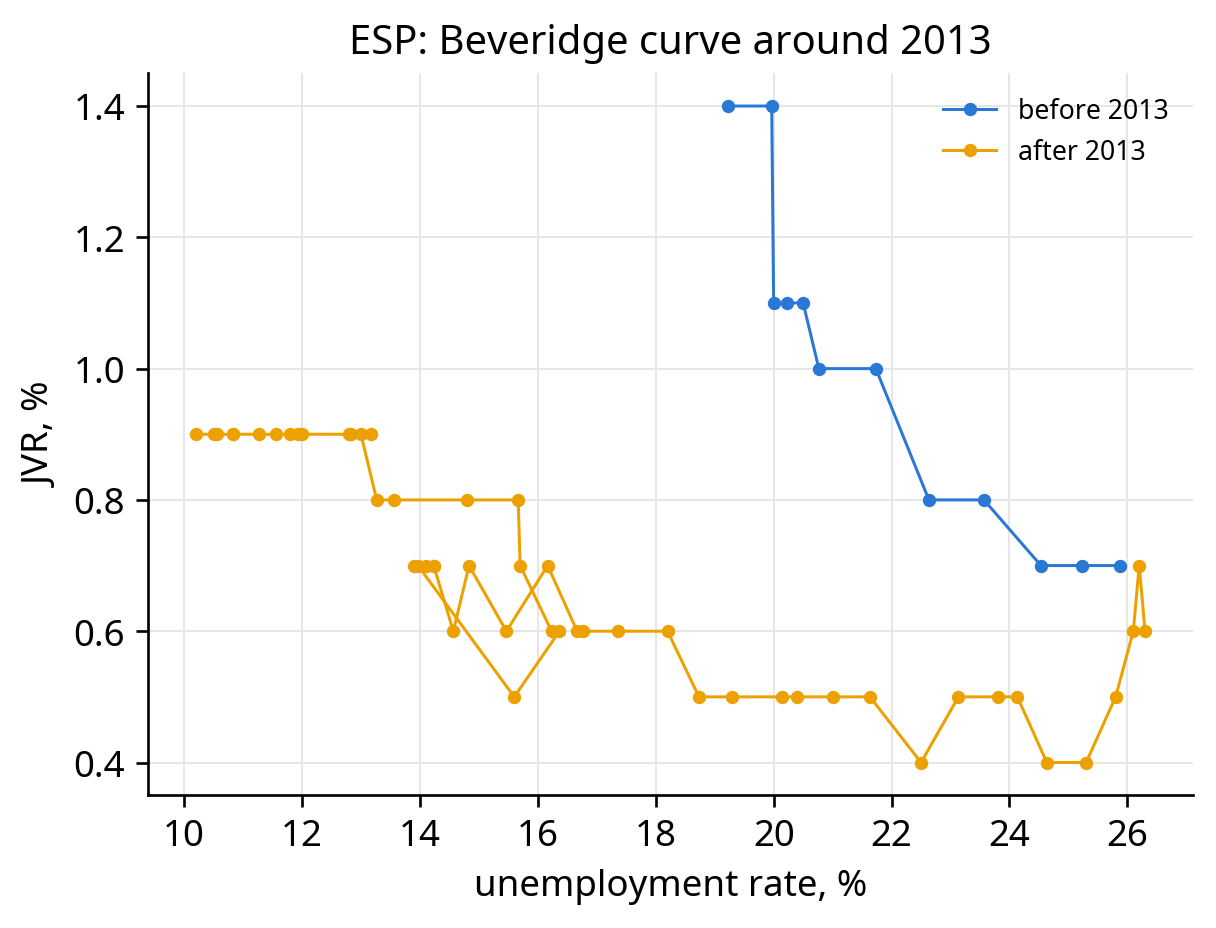

ESP: 12 quarters before, 52 after; mean urate 22.0% -> 16.7%


In [6]:
# ← Change these:
COUNTRY_TRY = "ESP"
SPLIT_TRY = "2013-01-01"

g = eu[eu["code"] == COUNTRY_TRY].sort_values("date")
assert len(g) > 12, f"{COUNTRY_TRY}: not enough quarters in the freeze"
pre = g[g["date"] < SPLIT_TRY]
post = g[g["date"] >= SPLIT_TRY]
fig, ax = plt.subplots(figsize=(5.2, 4.0))
if len(pre):
    ax.plot(pre["urate"], pre["jvr"], "-o", color="#2a78d6", ms=3,
            lw=0.9, label=f"before {SPLIT_TRY[:4]}")
ax.plot(post["urate"], post["jvr"], "-o", color="#eda100", ms=3, lw=0.9,
        label=f"after {SPLIT_TRY[:4]}")
ax.set_xlabel("unemployment rate, %"); ax.set_ylabel("JVR, %")
ax.set_title(f"{COUNTRY_TRY}: Beveridge curve around {SPLIT_TRY[:4]}")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"{COUNTRY_TRY}: {len(pre)} quarters before, {len(post)} after; "
      f"mean urate {pre['urate'].mean() if len(pre) else float('nan'):.1f}% "
      f"-> {post['urate'].mean():.1f}%")

**Prompts.** (1) *Basic*: color the US scatter by `quits_rate` instead
of era. Why do quits track tightness so closely that the "quits rate"
became shorthand for worker bargaining power? (2) *Intermediate*:
re-estimate the matching elasticity on pre-2020 data only, then on the
full sample. Which direction does COVID move $\hat\alpha$, and what does
that say about pooling across matching regimes? (3) *Stretch*: the
steady-state locus above implies $u^{*} = s/(s + \mu\theta^{1-\alpha})$.
Back out the implied $\mu_t$ month by month from JOLTS ($s$ from
layoffs + quits, $f$ from hires/U), and ask whether the post-2021
vertical descent was falling $\mu$ recovering (Figura-Waller) or excess
demand cooling (Blanchard et al.) — the notebook's data cannot fully
separate them, which is exactly why the debate happened.

**How comprehensive is this?** `puremacro.fetch.jolts` also serves
hires/quits/layoffs by 13 industry supersectors (SA and NSA);
`fetch_eurostat_vacancies` serves vacancy *counts* and occupied posts by
NACE section and size class; the LFS urate panels
(`fetch_eurostat_lfs_panel`, `fetch_oecd_lfs_panel`,
`fetch_labor_panel_union`) extend the u-axis to the OECD; and the
state-dependent local projections of notebook 07 (`puremacro.lp`) are
the natural next step for asking whether shocks matter differently in
tight and slack regions of this curve.